<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" /> 
    
    
## <font color='navy'> Repaso Pandas
    
### <font color='navy'> Portafolios de Inversión

    Mtro. Sean Nicolás González Vázquez
    

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://upload.wikimedia.org/wikipedia/commons/e/ed/Pandas_logo.svg" width="400px" height="400px" />

> Hoy nos dedicaremos a recordar funciones clave la librería de Python para análisis de datos: **Pandas**. Durante el transcurso de la asignatura haremos uso extensivo de datos históricos de precios y rendimientos de activos financieros, por tanto es importante tener un buen manejo de pandas.

Referencias:
- https://pandas.pydata.org/
- https://towardsdatascience.com/data-science-with-python-intro-to-loading-and-subsetting-data-with-pandas-9f26895ddd7f
___


# 0. Motivación

En finanzas, normalmente trabajamos con grandes cantidades de datos (precios, rendimientos y fundamentales). 

Los datos que debemos cargar pueden guardarse de muchas maneras distintas: archivos CSV, archivos de Excel, etcétera. Incluso, los datos pueden estar disponibles a través de API's (Application Programming Interface). 

Para trabajar con datos, se hace necesario representarlos en una estructura tabular (cualquier cosa con forma de tabla con filas y columnas).

En algunos casos, los datos ya están en forma tabular y es más fácil cargarlos. En otros, debemos trabajar con datos no estructurados o que no están organizados de una manera determinada (texto plano, imágenes, audio, etcétera).

En esta clase nos vamos a concentrar en cargar datos desde archivos xlsx y desde la API de Yahoo Finance.

## Pandas


In [129]:
# Importar pandas
import pandas as pd

___
# 1. Importando datos

En CANVAS, podrán encontrar el archivo "customers_data.xlsx" que cuenta con la información de los clientes de cierta empresa.

El primer paso para comenzar a trabajar con datos es importarlos. Lo podemos hacer con la función `pd.read_excel()`, ya que es un archivo .xlsx, en caso de necesitar exportar un archivo separado por comas (.csv) se puede utilizar la función `pd.read_csv()`:

In [130]:
# Importar customers_data.xlsx
df = pd.read_excel('customers_data.xlsx')

In [131]:
# Observar datos
df.head()

,Unnamed: 0,customer,zip_code,join_date,date_of_birth
0,0,Pedro,60091,2011-04-17 10:48:00,1994-07-18
1,1,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
2,2,Luis,13244,2011-08-13 15:42:00,2012-11-21
3,3,Cesar,60091,2011-04-08 20:08:00,2010-08-15
4,4,Pablo,60091,2010-07-17 05:27:00,1984-07-28


Bien, ya tenemos los datos cargados, sin embargo, se ve algo raro. 

¿Qué es esta columna "Unnamed: 0"?

Para especificar que esta columna corresponde al índice, podemos usar el argumento `index_col`, o bien, la función `set_index`, debido a que los datos ya fueron exportados.

In [132]:
# Importar customers_data.xlsx, haciendo uso del argumento index_col
df = df.drop('Unnamed: 0', axis=1)
df.head()

,customer,zip_code,join_date,date_of_birth
0,Pedro,60091,2011-04-17 10:48:00,1994-07-18
1,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
2,Luis,13244,2011-08-13 15:42:00,2012-11-21
3,Cesar,60091,2011-04-08 20:08:00,2010-08-15
4,Pablo,60091,2010-07-17 05:27:00,1984-07-28


In [133]:
# Utilizar set_index, tener cuidado

In [134]:
# Ver data

In [135]:
# Tipo de objeto con que importa pandas los archivos
type(df)

pandas.core.frame.DataFrame

___
# 2. Indización y selección de datos

Hay muchas formas de las cuales podemos seleccionar datos de DataFrames. Veremos, la forma basada en corchetes ([]) y en los métodos `loc()` (nombres de columnas) y `iloc()` (índices de columnas).

Podemos empezar seleccionando con corchetes:

In [136]:
# Seleccionar la columna date_of_birth
date = df['date_of_birth']
date

0   1994-07-18
1   1986-08-18
2   2012-11-21
3   2010-08-15
4   1984-07-28
Name: date_of_birth, dtype: datetime64[ns]

In [137]:
# Tipo de objeto
type(date)

pandas.core.series.Series

Las Series de pandas son arreglos unidimensionales que pueden ser etiquetados. En algunos casos, querremos seleccionar solo una columna pero mantener esta selección en un DataFrame. En este caso podemos pasar una lista con un solo elemento:

In [138]:
# Seleccionar la columna date_of_birth como DataFrame
date_df = df[['date_of_birth']]
date_df

,date_of_birth
0,1994-07-18
1,1986-08-18
2,2012-11-21
3,2010-08-15
4,1984-07-28


In [139]:
# Tipo de objeto
type(date_df)

pandas.core.frame.DataFrame

Finalmente, seleccionamos dos columnas:

In [140]:
# Seleccionar las columnas date_of_birth y zip_code
df[['date_of_birth', 'zip_code']]

,date_of_birth,zip_code
0,1994-07-18,60091
1,1986-08-18,13244
2,2012-11-21,13244
3,2010-08-15,60091
4,1984-07-28,60091


Muy bien, ya vimos que los corchetes son útiles. También existen los poderosos métodos `loc` y `iloc`, que nos dan el poder de seleccionar ambos a la vez: columnas y filas.

¿En qué se diferencian?

- El método `loc` nos permite seleccionar filas y columnas de nuestros datos basados en etiquetas. Primero, se deben especificar las etiquetas de las filas, y luego las de las columnas.

- El método `iloc` nos permite hacer lo mismo pero basado en índices enteros de nuestro DataFrame (como si fueran matrices).

Como antes, si queremos seleccionar todas las filas, o columnas, simplemente escribimos `:` en el lugar adecuado.

Mejor con ejemplos:

Para un mejor entendimiento de esta parte, reetiquetaremos la numeración de clientes con una "numeración" alfabética. Es decir: 1 = A, 2 = B, ..., 5 = E.

In [141]:
# Utilizar data.index
df.index = ['A', 'B', 'C', 'D', 'E']

In [142]:
# Observar datos
df.head()

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21
D,Cesar,60091,2011-04-08 20:08:00,2010-08-15
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


Ahora sí.

Seleccionemos el primer cliente con ambos métodos:

In [143]:
# Primer cliente con loc como serie
df.loc[['A']] # .loc[[nombre_filas], [nombre_columnas]]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18


In [144]:
# Primer cliente con iloc como data frame
df.iloc[[0]] # .iloc[[índice_filas], [índice_columnas]]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18


Ahora, seleccionemos los clientes A y C con ambos métodos (.loc y .iloc):

In [145]:
# Clientes A y C con loc
df.loc[['A', 'C']]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21


In [146]:
# Clientes A y C con iloc
df.iloc[[0, 2]]

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21


Ahora, de los clientes B y E, queremos su zip_code y su join_date:

In [147]:
# loc
df.loc[['B', 'D'], ['zip_code', 'join_date']]

,zip_code,join_date
B,13244,2012-04-15 23:31:00
D,60091,2011-04-08 20:08:00


In [148]:
# iloc
df.iloc[[1, 3], [1, 2]]

,zip_code,join_date
B,13244,2012-04-15 23:31:00
D,60091,2011-04-08 20:08:00


___
# 3. Filtrado de datos

Los operadores de comparación pueden ser utilizados con Series de pandas. 

Esto resulta ser súper útil para filtrar datos con ciertas condiciones específicas (esto lo veremos enseguida). 

Por ahora, veremos que al usar operadores de comparación con Series, el resultado será Series booleanas. Es decir, cada elemento de dichas series será `True` si la condición se satisface, y `Falso` de lo contrario.

Una vez tenemos la serie boolena, podemos aplicarla para la selección de filas, obteniendo un DataFrame filtrado como resultado.

**Ejemplos**

¿Cuáles clientes son mayores de 18 años?

In [149]:
# Ver tabla
df.head()

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21
D,Cesar,60091,2011-04-08 20:08:00,2010-08-15
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


In [150]:
# Cuales son mayores de edad?
mayor_edad =df['date_of_birth'] < '2008-01-01'
mayor_edad

A     True
B     True
C    False
D    False
E     True
Name: date_of_birth, dtype: bool

In [151]:
# Filtrar data frame
df_mayor_edad = df[mayor_edad]
df_mayor_edad

,customer,zip_code,join_date,date_of_birth
A,Pedro,60091,2011-04-17 10:48:00,1994-07-18
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
E,Pablo,60091,2010-07-17 05:27:00,1984-07-28


¿Cuáles clientes viven en la zona con CP 13244?

In [152]:
# Zone True or False
cp = df['zip_code'] == 13244
cp 

A    False
B     True
C     True
D    False
E    False
Name: zip_code, dtype: bool

In [153]:
# Filtrar data frame
df_cp = df[cp]

In [154]:
df_cp

,customer,zip_code,join_date,date_of_birth
B,Alfonso,13244,2012-04-15 23:31:00,1986-08-18
C,Luis,13244,2011-08-13 15:42:00,2012-11-21


# 4.- Importación de Datos desde Yahoo Finance

La librería de Yahoo Finance `yfinance`, nos permite descargar directamente datos desde la base de datos de Yahoo Finance, la documentación de la paquetería es la siguiente:

+ https://pypi.org/project/yfinance/

Para instalar la librería desde tu computadora utiliza el comando:

`!pip install yfinance`

In [155]:
# Importar y/o instalar yfinance
# Instalar: !pip install yfinance
# Si marca error: !pip install yfinance --upgrade 

In [156]:
import yfinance as yf

Con el método de `yf.download`, podemos descargar la información de cualquier activo financiero que cotice en la bolsa de Estados Unidos (**NYSE**), utilizando el *Ticker* del activo, vamos a intentarlo para una acción:

In [157]:
# Descargar información para un activo y guardar en variable "price"
prices = yf.download('PLTR', start='2026-01-01', end='2026-08-18')
prices

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,PLTR,PLTR,PLTR,PLTR,PLTR
Date,,,,,
2026-01-02,167.860001,181.350006,166.350006,181.300003,60634100
2026-01-05,174.039993,175.820007,171.789993,174.880005,39511700
2026-01-06,179.710007,180.190002,174.770004,175.759995,34838600
2026-01-07,181.679993,187.279999,177.660004,179.800003,45349000
2026-01-08,176.860001,185.660004,174.369995,185.615005,47304300
...,...,...,...,...,...
2026-08-11,174.940002,177.940002,172.720001,174.179993,43162500
2026-08-12,171.039993,175.089996,168.339996,174.070007,35220300


Notesé que la función descarga distinta información de los activos, como por ejemplo el Low, Close, Adj Close, etc. 

Vamos a analizar cada elemento para discutir cual es el más importante, a posteriori, vamos a filtrar el data frame por esta columna.

In [158]:
# Filtrar price por la columna más importante
prices = prices['Close']
prices

Ticker,PLTR
Date,
2026-01-02,167.860001
2026-01-05,174.039993
2026-01-06,179.710007
2026-01-07,181.679993
2026-01-08,176.860001
...,...
2026-08-11,174.940002
2026-08-12,171.039993
2026-08-13,179.009995


También podemos intentarlo para *n* cantidad de activos, además de la acción descargada en la parte anterior, vamos a descargar ahora la información de JP Morgan `JPM` y del índice Dow Jones `^DJI`, y filtrando por la columna determinada en la parte anterior.

In [159]:
# Descargar la información para la acción anterior, JPM y DJI.
prices = yf.download(['PLTR', 'NVDA', '^DJI'], start='2010-01-01', end='2026-08-18')['Close']
prices

[*********************100%***********************]  3 of 3 completed


Ticker,NVDA,PLTR,^DJI
Date,,,
2010-01-04,0.423290,NaN,10583.959961
2010-01-05,0.429472,NaN,10572.019531
2010-01-06,0.432219,NaN,10573.679688
2010-01-07,0.423748,NaN,10606.860352
2010-01-08,0.424664,NaN,10618.190430
...,...,...,...
2026-08-11,217.500000,174.940002,53791.851562
2026-08-12,224.089996,171.039993,53770.269531
2026-08-13,225.300003,179.009995,53839.988281


In [160]:
yf.download?

Signature:
yf.download(
    tickers,
    start=None,
    end=None,
    actions=False,
    threads=True,
    ignore_tz=None,
    group_by='column',
    auto_adjust=True,
    back_adjust=False,
    repair=False,
    keepna=False,
    progress=True,
    period='1mo if start & end None',
    interval='1d',
    prepost=False,
    rounding=False,
    timeout=10,
    session=None,
    multi_level_index=True,
) -> Optional[pandas.core.frame.DataFrame]
Docstring:
Download yahoo tickers
:Parameters:
    tickers : str, list
        List of tickers to download
    period : str
        Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        Default: '1mo' if start & end None
        Either Use period parameter or use start and end
    interval : str
        Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        Intraday data cannot extend last 60 days
    start: str
        Download start date string (YYYY-MM-DD) or _datetime, inclusive.
        Default is 99 years ago
       

Podemos observar en el dataframe anterior que tenemos valores nulos en algunos activos, esto debido a que los activos empezaron a cotizar en momentos históricos diferentes o no tenemos acceso al período solicitado. Vamos a filtrar el período para después del 2018.

In [161]:
# Filtrar df para los datos después del 2018
prices_2018 = prices[prices.index > '2018-01-01']
prices_2018

Ticker,NVDA,PLTR,^DJI
Date,,,
2018-01-02,4.922530,NaN,24824.009766
2018-01-03,5.246500,NaN,24922.679688
2018-01-04,5.274157,NaN,25075.130859
2018-01-05,5.318852,NaN,25295.869141
2018-01-08,5.481824,NaN,25283.000000
...,...,...,...
2026-08-11,217.500000,174.940002,53791.851562
2026-08-12,224.089996,171.039993,53770.269531
2026-08-13,225.300003,179.009995,53839.988281


Para no tener que filtrar siempre el dataframe, podemos directamente descargar la información para un periodo dato, utilizando los parámetros `start` y `ènd` de la función `yf.download()`

In [162]:
# Descargar información con un período dado
prices_1mo = yf.download(['PLTR', 'NVDA', '^DJI'], start='2010-01-01', end='2026-08-18', interval='1mo')['Close']
prices_1mo

[*********************100%***********************]  3 of 3 completed


Ticker,NVDA,PLTR,^DJI
Date,,,
2010-01-01,0.352322,NaN,10067.330078
2010-02-01,0.370866,NaN,10325.259766
2010-03-01,0.398337,NaN,10856.629883
2010-04-01,0.359648,NaN,11008.610352
2010-05-01,0.300813,NaN,10136.629883
...,...,...,...
2026-04-01,199.337677,139.110001,49652.140625
2026-05-01,210.894211,156.539993,51032.460938
2026-06-01,200.089996,116.669998,52319.199219


Ahora, si queremos graficar la información con los precios de cierre ajustado para nuestras tres acciones, vamos a utilizar `matplotlib.pyplot`:

In [163]:
# Graficar precios usando matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

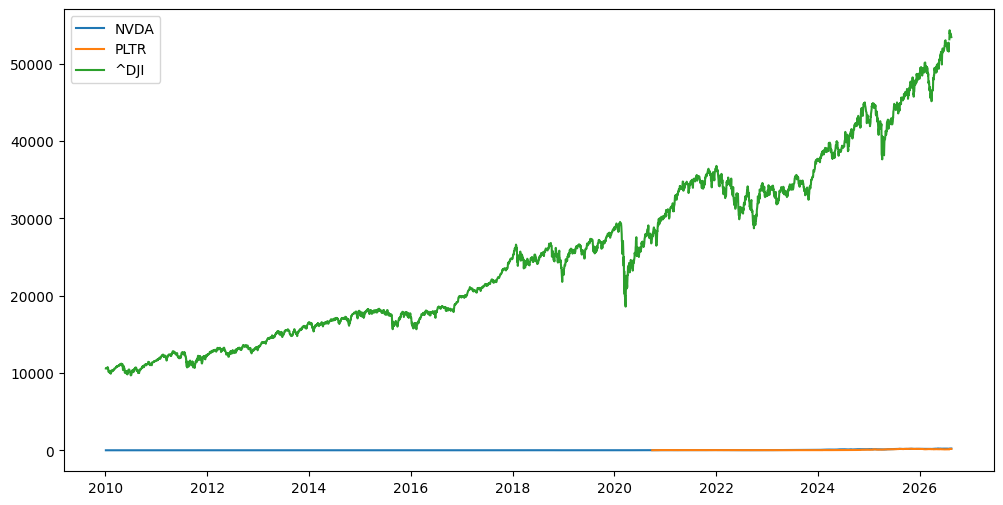

In [164]:
plt.figure(figsize=(12, 6))
plt.plot(prices, label=prices.columns)
plt.legend()
plt.show()

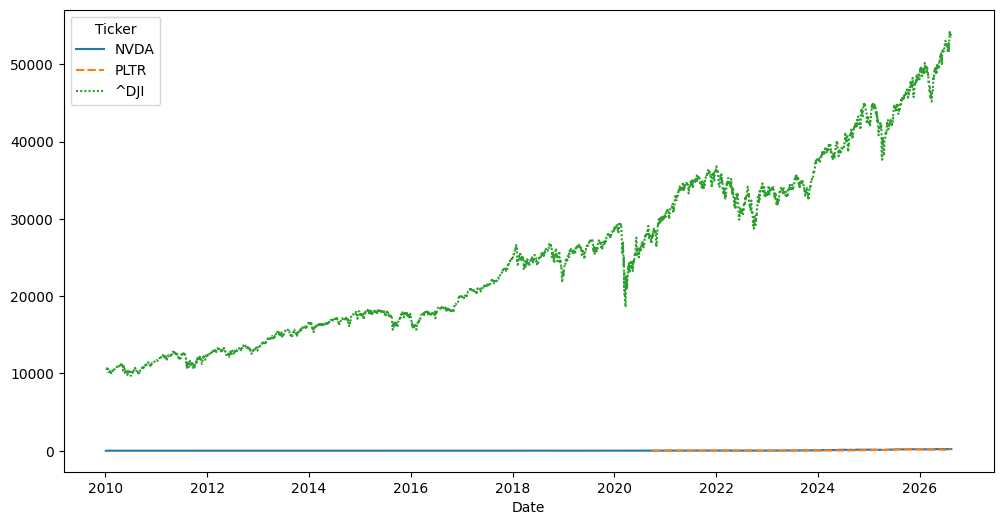

In [165]:
# Con seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=prices)
plt.show()

Como pueden observar, el Dow Jones se encuentra en una escala de precios muy por encima del resto de las acciones, hay que reflexionar: ¿A qué se debe esto? ¿Es útil comparar los precios de un activo financiero para decidir si invertir o no en este?

In [166]:
# Filtrar precios quitando el Dow Jones
prices_without_dji = prices.drop('^DJI', axis=1)

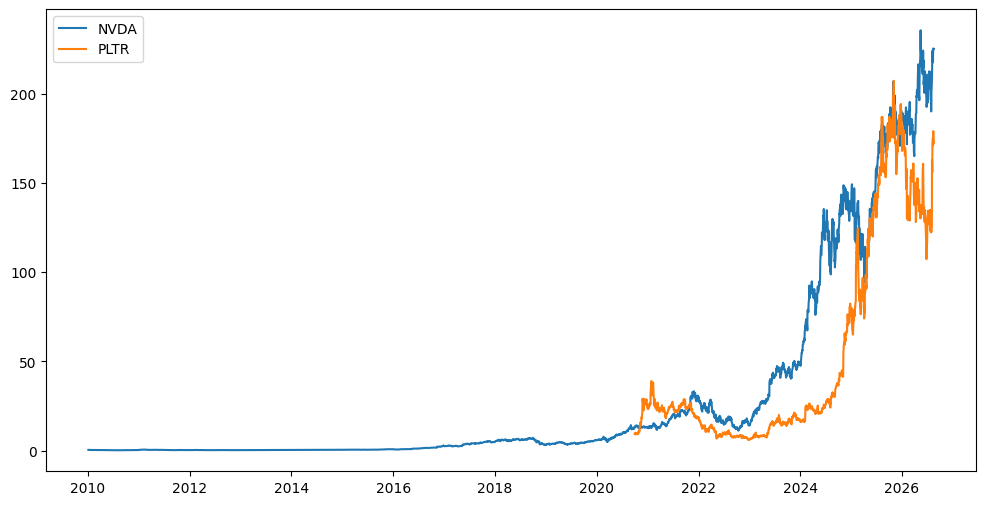

In [167]:
# Graficar precios usando matplotlib
plt.figure(figsize=(12, 6))
plt.plot(prices_without_dji, label=prices_without_dji.columns)
plt.legend()
plt.show()

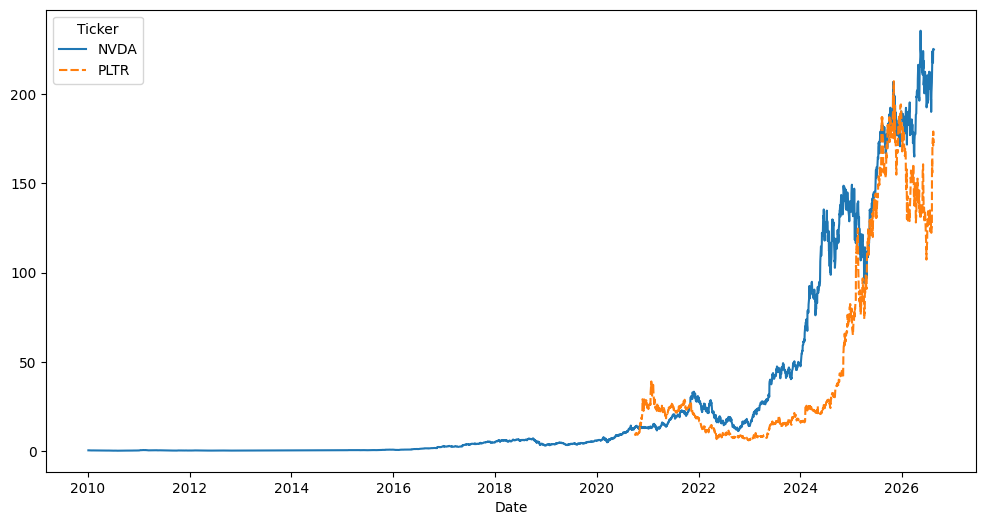

In [168]:
# Con seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=prices_without_dji)
plt.show()

> **Útil, ¿no?**.  Como habrán notado, la librería pandas es una herramienta extremadamente poderosa, no solo para el análisis de datos en Python, sino también para la manipulación y análisis de datos financieros. Durante el curso, utilizaremos esta librería para almacenar información sobre activos financieros, como precios, rendimientos, métricas de desempeño y más.

> En los últimos cinco años, la programación y las matemáticas han adquirido un papel crucial en las finanzas. De hecho, el **CFA Institute**, la organización de finanzas más prestigiosa a nivel mundial, ha incorporado temas de programación en Python y Ciencia de Datos en su certificación. Además, numerosas empresas bursátiles han comenzado a adoptar Python como el lenguaje preferido para el desarrollo de aplicaciones financieras. Esto subraya la importancia de comprender y dominar Python en el campo de la Ingeniería Financiera.

In [169]:
prices

Ticker,NVDA,PLTR,^DJI
Date,,,
2010-01-04,0.423290,NaN,10583.959961
2010-01-05,0.429472,NaN,10572.019531
2010-01-06,0.432219,NaN,10573.679688
2010-01-07,0.423748,NaN,10606.860352
2010-01-08,0.424664,NaN,10618.190430
...,...,...,...
2026-08-11,217.500000,174.940002,53791.851562
2026-08-12,224.089996,171.039993,53770.269531
2026-08-13,225.300003,179.009995,53839.988281


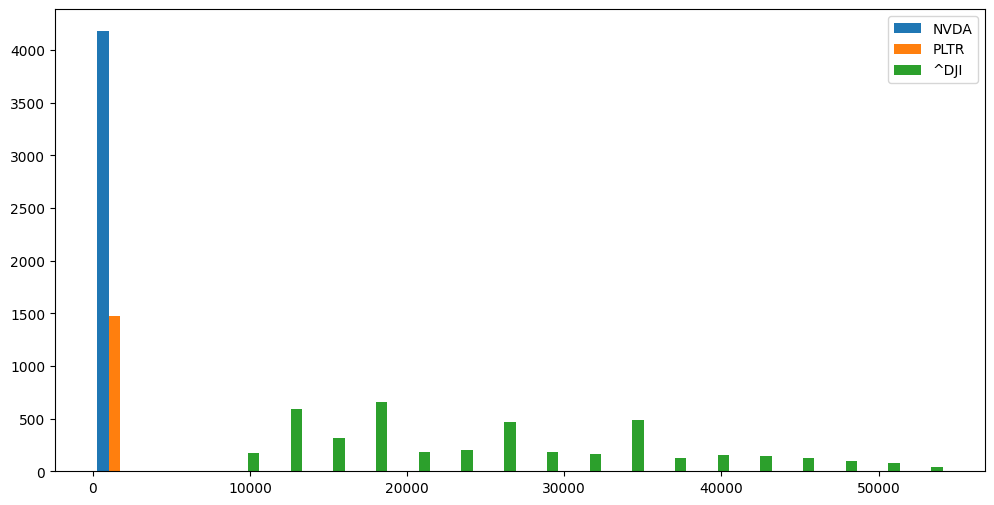

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(prices, label=prices.columns, bins=20)
plt.legend()
plt.show()

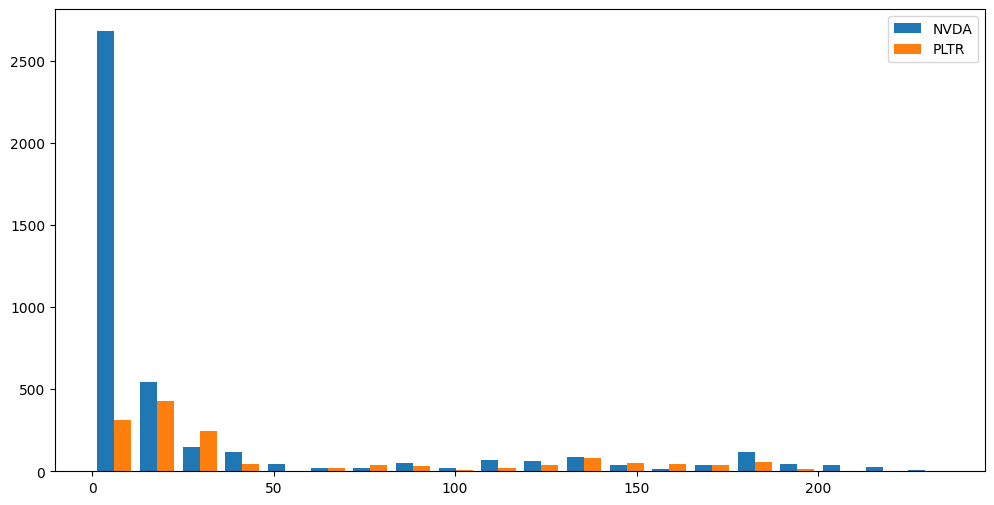

In [173]:
plt.figure(figsize=(12, 6))
plt.hist(prices_without_dji, label=prices_without_dji.columns, bins=20)
plt.legend()
plt.show()

Las distribuciones no son comprarables porque NVidia tiene mas historia que DIJ

Los precios no sirven para hacer una distribución de las ganancias